# Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
from diive.core.io.files import load_parquet
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats

# Load data

In [2]:
SOURCEDIR = r"../70_FINAL_MERGE"
FILENAME = r"71.1_FLUXES_METEO_MGMT_L4.1_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
maindf = load_parquet(filepath=FILEPATH)
maindf


Loaded .parquet file ..\70_FINAL_MERGE\71.1_FLUXES_METEO_MGMT_L4.1_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (0.347 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_FCH4_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED,FCH4_L3.1_L3.3_CUT_84_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_84_QCF_gfRF_ISFILLED,NEE_U16_f_reddyproc,Reco_U16_reddyproc,GPP_U16_f_reddyproc,NEE_U50_f_reddyproc,Reco_U50_reddyproc,GPP_U50_f_reddyproc,NEE_U84_f_reddyproc,Reco_U84_reddyproc,GPP_U84_f_reddyproc,LE_f_reddyproc,H_f_reddyproc,ET_f_reddyproc
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-12-31 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.465083,1.471708,0.006625,1.531928,1.515735,-0.016194,1.584801,1.552012,-0.032789,1.313335,1.188433,0.029150
2020-12-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.465083,1.470454,0.005372,1.531928,1.514467,-0.017462,1.584801,1.550737,-0.034063,1.301519,2.905173,0.028888
2021-01-01 00:15:00,1008.65,1.20907,0.023898,1219.53,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-17.0,-17.0,NaN,...,NaN,NaN,NaN,1.465083,1.470235,0.005152,1.531928,1.514245,-0.017684,1.584801,1.550514,-0.034287,0.055464,-3.557021,0.001231
2021-01-01 00:45:00,1008.64,1.20915,0.023896,1219.60,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-17.0,-17.0,NaN,...,NaN,NaN,NaN,1.465083,1.471799,0.006717,1.531928,1.515828,-0.016101,1.584801,1.552106,-0.032695,0.348332,-3.557021,0.007731
2021-01-01 01:15:00,1008.64,1.20925,0.023894,1219.70,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-17.0,-17.0,NaN,...,NaN,NaN,NaN,1.465083,1.473942,0.008859,1.531928,1.517995,-0.013933,1.584801,1.554285,-0.030515,-0.038865,-3.557021,-0.000863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:45:00,1008.89,1.21242,0.023828,1223.20,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-16.0,-16.0,NaN,...,NaN,NaN,NaN,1.432823,1.615999,0.183175,1.370211,1.626682,0.256471,1.348048,1.636257,0.288208,-0.853410,-5.293847,-0.018971
2023-12-31 22:15:00,1008.98,1.21206,0.023834,1222.94,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-16.0,-16.0,NaN,...,NaN,NaN,NaN,0.593252,1.674743,1.081492,0.593252,1.684758,1.091506,0.593252,1.693603,1.100351,-1.187178,-3.587753,-0.026404
2023-12-31 22:45:00,1009.08,1.21061,0.023861,1221.60,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-16.0,-16.0,NaN,...,NaN,NaN,NaN,1.295956,1.747225,0.451269,1.295956,1.756364,0.460408,1.295956,1.764261,0.468305,-0.409499,-6.293662,-0.009113


# Define time interval

In [3]:
start_date = '2022-08-30'
end_date = '2023-10-05'
maindf = maindf[start_date:end_date].copy()

# GAPFILLING CHECKS

## FN2O

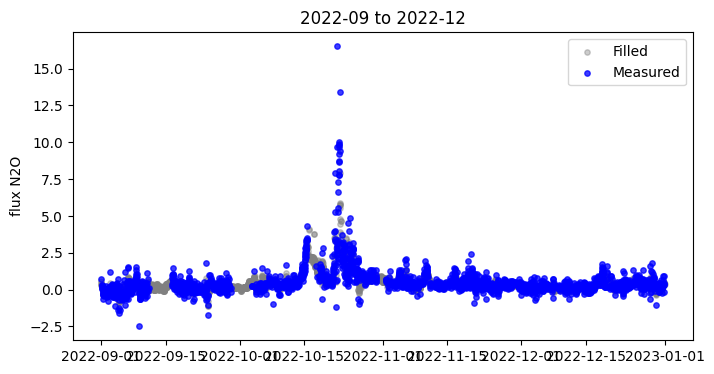

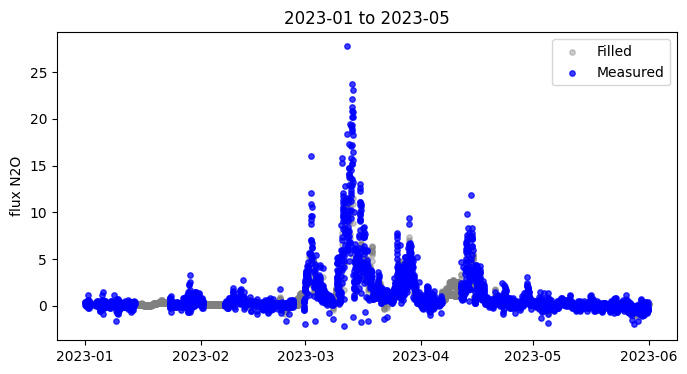

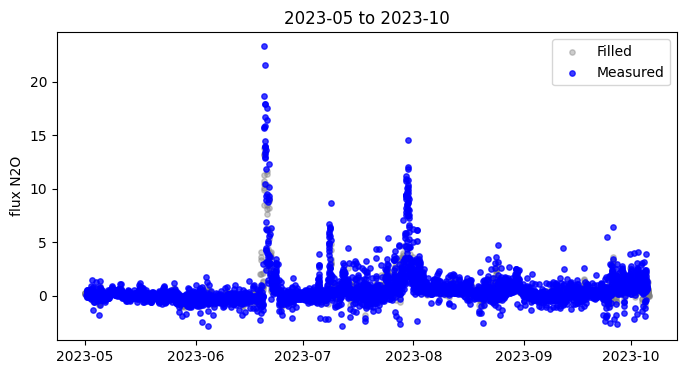

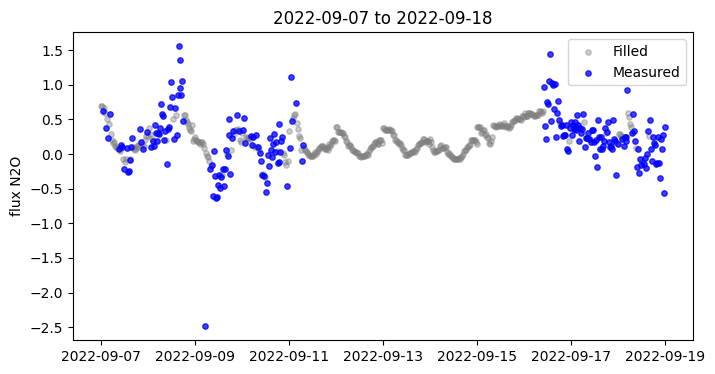

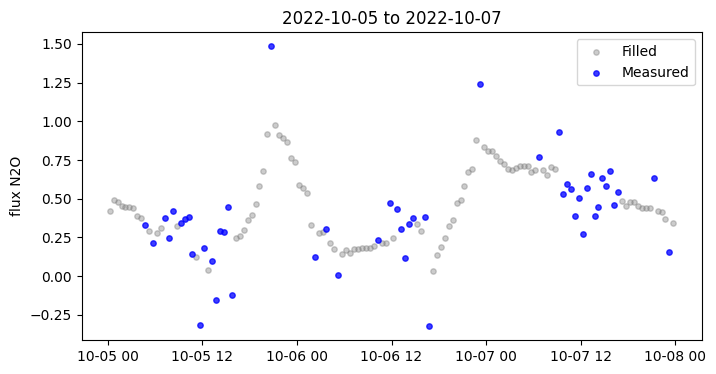

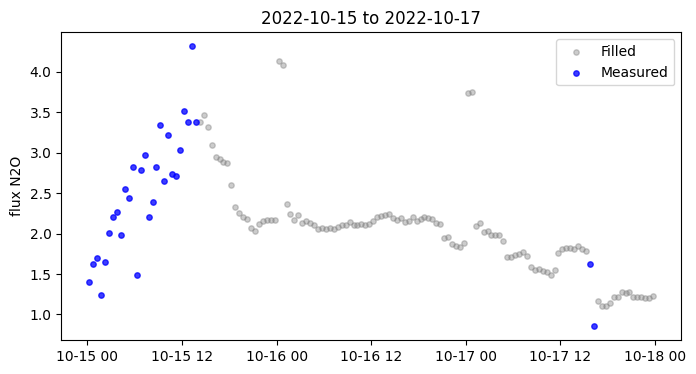

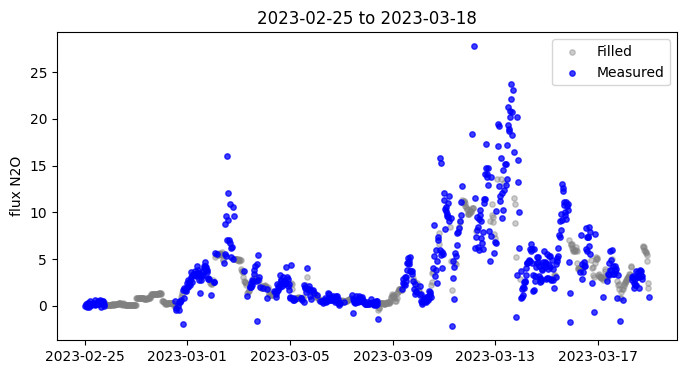

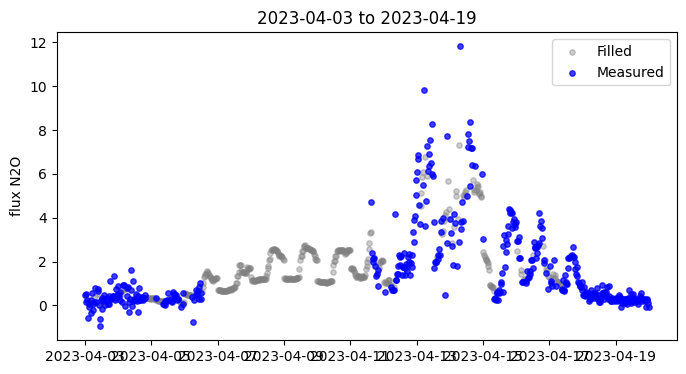

In [4]:
# Define periods
periods = [
    ('2022-09', '2022-12'),
    ('2023-01', '2023-05'),
    ('2023-05', '2023-10'),
    ('2022-09-07', '2022-09-18'),
    ('2022-10-05', '2022-10-07'),
    ('2022-10-15', '2022-10-17'),
    ('2023-02-25', '2023-03-18'),  # First fertilization
    ('2023-04-03', '2023-04-19')   # Second fertilization
]

# Loop through each period and plot
for start, end in periods:
    indat = maindf[start:end]
    plt.figure(figsize=(8,4))

        # Plot filled data (flag == 1)
    plt.scatter(
        indat.index[indat['FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED'] == 1], 
        indat['FN2O_L3.1_L3.3_CUT_50_QCF_gfRF'][indat['FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED'] == 1], 
        color='grey', label=f'Filled', alpha=0.4, s=15
    )

    # Plot original data (flag == 0)
    plt.scatter(
        indat.index[indat['FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED'] == 0], 
        indat['FN2O_L3.1_L3.3_CUT_50_QCF_gfRF'][indat['FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED'] == 0], 
        color='blue', label=f'Measured', alpha=0.76, s=15
    )
    
    # Formatting
    plt.legend()
    plt.ylabel('flux N2O')
    plt.title(f'{start} to {end}')
    plt.show()



## NEE (MDS Vs RF)

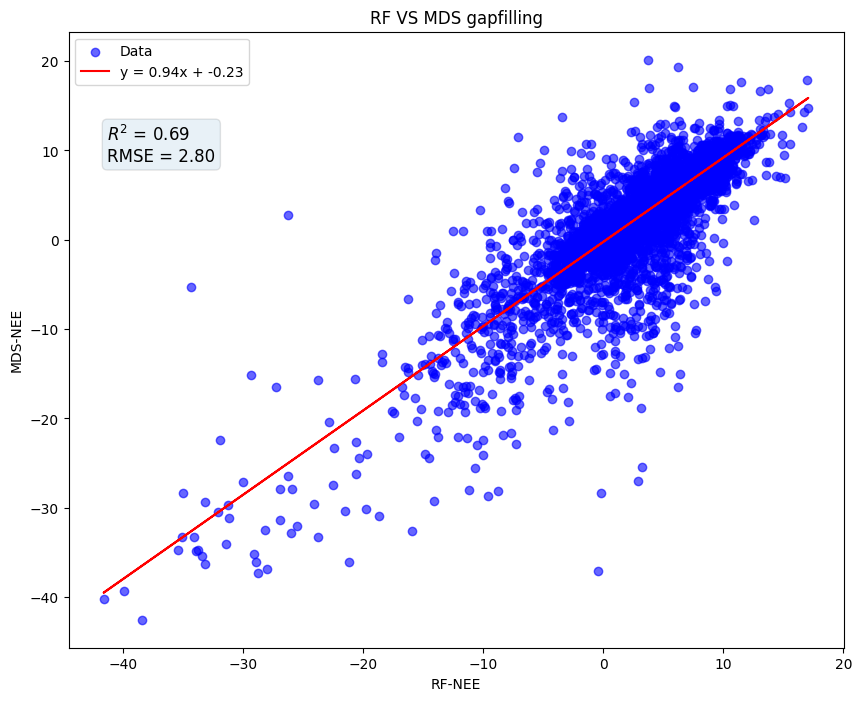

In [5]:
# Filter only filled data
filled_df = maindf[maindf['FLAG_NEE_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED']==1]


# Define x and y
x = filled_df['NEE_L3.1_L3.3_CUT_50_QCF_gfRF'].values.reshape(-1, 1)
y = filled_df['NEE_U50_f_reddyproc'].values

# Perform linear regression using scipy.stats.linregress
slope, intercept, r_value, p_value, std_err = stats.linregress(x.flatten(), y)

# Compute predicted values manually
y_pred = slope * x.flatten() + intercept

# Calculate R² and RMSE
r2 = r_value ** 2
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

# Plot data and regression line
plt.figure(figsize=(10, 8))
plt.scatter(x, y, label="Data", color="blue", alpha=0.6)
plt.plot(x, y_pred, color="red", label=f"y = {slope:.2f}x + {intercept:.2f}")
plt.xlabel("RF-NEE")
plt.ylabel("MDS-NEE")
plt.title("RF VS MDS gapfilling")
plt.legend()

# Add R², RMSE, and p-value text
textstr = f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f}"
plt.text(0.05, 0.85, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle="round", alpha=0.1))

# Show plot
plt.show()
